<a href="https://colab.research.google.com/github/lizeth75/PROYECTO_ML/blob/main/AnsiedadGenZT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Variables que afectan a la generación Z**

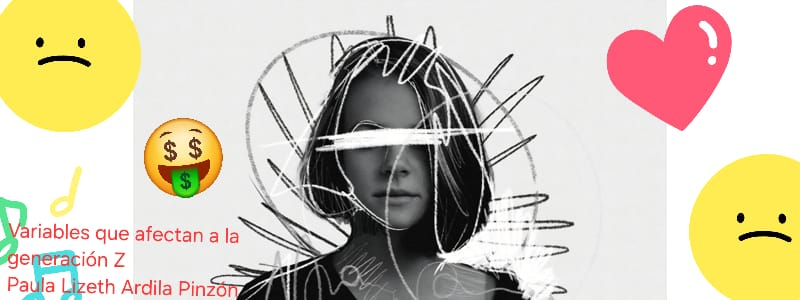

Paula Lizeth Ardila Pinzon 2243586




Análisis de la generacion Z mediante caracteristicas fisicas, comportaminetos y sentimientos en personas rondando edades de 18 años a 26 años.

#**Librerias**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder #  Normalizacion de datos, texto a numeros
from sklearn.metrics import accuracy_score, classification_report #porcentaje de aciertos , precision
from sklearn.model_selection import train_test_split, cross_val_score, KFold     #divide en entrena-precision, evalarML divide los datos
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(21)
tf.keras.utils.set_random_seed(21)
np.random.seed(21)


#**Dataset - Drive**

In [ ]:
id = "16E0_0EDM96ImJFgQjjUcD8C8SNLSiyHX"
url = f"https://drive.google.com/uc?export=download&id={id}"

df = pd.read_csv(url)

#  **Información del dataset**

In [ ]:
df.shape

(798, 22)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Student_Working_Status',
       'Daily_Social_Media_Hours', 'Screen_Time_Hours',
       'Night_Scrolling_Frequency', 'Online_Gaming_Hours',
       'Content_Type_Preference', 'Exercise_Frequency_per_Week',
       'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day',
       'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score',
       'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level',
       'Emotional_Fatigue_Score', 'Wellbeing_Index', 'Burnout_Risk'],
      dtype='object')

In [ ]:
df.head()

,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [ ]:
df.describe()

,Age,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,21.874687,3.980789,6.969261,2.954499,1.643008,2.939649,6.533559,1.492895,5.943885,5.016028,4.755313,5.120301,4.402556,6.555338,5.100363,5.582820,3.873835
std,2.598974,1.526823,1.807569,1.154964,1.306798,1.458441,1.266371,0.936090,1.943051,1.115440,1.295973,1.296827,1.340460,1.504249,1.270028,1.418254,1.263189
min,18.000000,0.500000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.020000,1.000000,1.040000,1.000000,2.520000,1.380000,1.480000,1.000000
25%,20.000000,2.975000,5.762500,2.210000,0.492500,1.942500,5.692500,0.730000,4.632500,4.250000,3.850000,4.230000,3.420000,5.472500,4.232500,4.642500,3.005000
50%,22.000000,3.890000,6.965000,2.935000,1.515000,2.975000,6.570000,1.440000,5.960000,4.980000,4.775000,5.105000,4.410000,6.565000,5.080000,5.615000,3.885000
75%,24.000000,5.070000,8.190000,3.820000,2.560000,3.940000,7.417500,2.167500,7.160000,5.760000,5.655000,5.960000,5.300000,7.577500,5.930000,6.510000,4.730000
max,26.000000,9.050000,12.560000,7.000000,5.760000,7.000000,10.000000,4.790000,11.690000,8.460000,8.880000,9.390000,8.150000,10.000000,8.970000,10.000000,7.750000


In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          798 non-null    int64  
 1   Gender                       798 non-null    object 
 2   Country                      798 non-null    object 
 3   Student_Working_Status       798 non-null    object 
 4   Daily_Social_Media_Hours     798 non-null    float64
 5   Screen_Time_Hours            798 non-null    float64
 6   Night_Scrolling_Frequency    798 non-null    float64
 7   Online_Gaming_Hours          798 non-null    float64
 8   Content_Type_Preference      798 non-null    object 
 9   Exercise_Frequency_per_Week  798 non-null    float64
 10  Daily_Sleep_Hours            798 non-null    float64
 11  Caffeine_Intake_Cups         798 non-null    float64
 12  Study_Work_Hours_per_Day     798 non-null    float64
 13  Overthinking_Score  

##**Filtrado**

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Student_Working_Status,0
Daily_Social_Media_Hours,0
Screen_Time_Hours,0
Night_Scrolling_Frequency,0
Online_Gaming_Hours,0
Content_Type_Preference,0
Exercise_Frequency_per_Week,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#**Información estadística**




In [ ]:
# solo columnas numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
print("Columnas numéricas encontradas:", columnas_numericas)

# lista para almacenar resultados
resultados = []

for col in columnas_numericas:
    # Verificar si tiene suficientes valores unicos
    if df[col].nunique() > 5:
        q1 = df[col].quantile(0.25)  # el 25% de los datos están por debajo de tal valor
        q3 = df[col].quantile(0.75) # el 75% de los datos están por debajo de tal valor
        iqr = q3 - q1   #IQR -> #   Rango intercualtil, dispersion de los datos

        resultados.append({
            'Variable': col,
            'Q1': round(q1, 2),
            'Q3': round(q3, 2),
            'IQR': round(iqr, 2)
        })

# Crear DataFrame con los resultados
tabla_resultados = pd.DataFrame(resultados)
print("\n TABLA DE ESTADÍSTICAS POR VARIABLE:")
print(tabla_resultados.to_string(index=False))

Columnas numéricas encontradas: ['Age', 'Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day', 'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score', 'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level', 'Emotional_Fatigue_Score', 'Wellbeing_Index']

 TABLA DE ESTADÍSTICAS POR VARIABLE:
                   Variable    Q1    Q3  IQR
                        Age 20.00 24.00 4.00
   Daily_Social_Media_Hours  2.98  5.07 2.10
          Screen_Time_Hours  5.76  8.19 2.43
  Night_Scrolling_Frequency  2.21  3.82 1.61
        Online_Gaming_Hours  0.49  2.56 2.07
Exercise_Frequency_per_Week  1.94  3.94 2.00
          Daily_Sleep_Hours  5.69  7.42 1.72
       Caffeine_Intake_Cups  0.73  2.17 1.44
   Study_Work_Hours_per_Day  4.63  7.16 2.53
         Overthinking_Score  4.25  5.76 1.51
              Anxiety_Score  3.85  5.66 1.8

#**Gráficas**

In [ ]:
# Histograma de edad
fig = px.histogram(df, x='Age', color='Gender',
                   title='Distribución de Edad por Género',
                   nbins=10)
fig.show()

In [ ]:
# Boxplot de horas de sueño por nivel de burnout
fig = px.box(df, x='Burnout_Risk', y='Daily_Sleep_Hours',
             color='Burnout_Risk', title='Horas de Sueño por Nivel de Burnout',
             points='all')  # Muestra todos los puntos
fig.show()

In [ ]:
# Seleccionar columnas numéricas
numeric_cols = ['Age', 'Daily_Social_Media_Hours', 'Screen_Time_Hours',
                'Night_Scrolling_Frequency', 'Anxiety_Score',
                'Mood_Stability_Score', 'Wellbeing_Index']

# Calcular correlación
corr_matrix = df[numeric_cols].corr()

# Heatmap
fig = px.imshow(corr_matrix,
                text_auto=True,
                color_continuous_scale='RdBu_r',
                title='Matriz de Correlación - Variables de Salud Mental',
                aspect='auto')
fig.show()

In [ ]:
# Promedio de ansiedad por edad
df_age = df.groupby('Age')['Anxiety_Score'].mean().reset_index()
fig = px.line(df_age, x='Age', y='Anxiety_Score',
              title='Promedio de Ansiedad por Edad',
              markers=True)
fig.show()

In [ ]:
# Proporción de Burnout Risk
burnout_counts = df['Burnout_Risk'].value_counts().reset_index()
burnout_counts.columns = ['Burnout_Risk', 'count']

fig = px.pie(burnout_counts, values='count', names='Burnout_Risk',
             title='Distribución de Niveles de Burnout',
             hole=0.3)  # Donut chart
fig.show()

In [ ]:
# Conteo por país y nivel de burnout
df_country = df.groupby(['Country', 'Burnout_Risk']).size().reset_index(name='count')
fig = px.bar(df_country, x='Country', y='Burnout Risk', color='Burnout_Risk',
             title='Distribución de Burnout Risk por País',
             barmode='group')
fig.show()

# Promedio de ansiedad por género
df_gender = df.groupby('Gender')['Anxiety_Score'].mean().reset_index()
fig = px.bar(df_gender, x='Gender', y='Anxiety_Score',
             title='Promedio de Ansiedad por Género',
             color='Gender',
             text_auto='.2f')
fig.show()

#**Modelos supervisados**





In [ ]:

for col in ['Gender', 'Country', 'Student_Working_Status', 'Content_Type_Preference']:
  if col in df.columns:
    df[col] = pd.factorize(df[col])[0]

y = df["Burnout_Risk"]
X = df.drop(columns=["Burnout_Risk"])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# MODELOS DE MACHINE LEARNING

# Diccionario para almacenar resultados
results = {} #métricas finales
models_info = {} #mejores parámetros

#  DECISION TREE

max_depth_values = [3, 5, 7, 10, 15, 20]

dt_results = {}
for max_depth in max_depth_values:
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=21) # crear
    dt.fit(X_train_scaled, y_train) #entrenar
    acc = accuracy_score(y_test, dt.predict(X_test_scaled)) #evaluar

    dt_results[max_depth] = acc #gguardar
    print(f"max_depth={max_depth}: Accuracy = {acc:.4f}")

# Mejor Decision Tree
best_max_depth = max(dt_results, key=dt_results.get)
best_dt = DecisionTreeClassifier(max_depth=best_max_depth, random_state=21)
best_dt.fit(X_train_scaled, y_train)

acc_dt = accuracy_score(y_test, best_dt.predict(X_test_scaled))

results['Decision Tree'] = acc_dt #guardar
models_info['Decision Tree'] = {'max_depth': best_max_depth}

print(f"\n Mejor max_depth: {best_max_depth} | Accuracy: {acc_dt:.4f}")



max_depth=3: Accuracy = 1.0000
max_depth=5: Accuracy = 1.0000
max_depth=7: Accuracy = 1.0000
max_depth=10: Accuracy = 1.0000
max_depth=15: Accuracy = 1.0000
max_depth=20: Accuracy = 1.0000

 Mejor max_depth: 3 | Accuracy: 1.0000


In [ ]:
#  RANDOM FOREST

n_estimators_values = [50, 100, 150, 200]

rf_results = {}
for n in n_estimators_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=21)
    rf.fit(X_train_scaled, y_train)

    acc = accuracy_score(y_test, rf.predict(X_test_scaled))

    rf_results[n] = acc
    print(f"n_estimators={n}: Accuracy = {acc:.4f}")

# Mejor Random Forest
best_n = max(rf_results, key=rf_results.get)
best_rf = RandomForestClassifier(n_estimators=best_n, random_state=21)
best_rf.fit(X_train_scaled, y_train)

acc_rf = accuracy_score(y_test, best_rf.predict(X_test_scaled))
results['Random Forest'] = acc_rf
models_info['Random Forest'] = {'n_estimators': best_n}
print(f"\n Mejor n_estimators: {best_n} | Accuracy: {acc_rf:.4f}")

n_estimators=50: Accuracy = 0.9938
n_estimators=100: Accuracy = 0.9938
n_estimators=150: Accuracy = 0.9938
n_estimators=200: Accuracy = 0.9938

 Mejor n_estimators: 50 | Accuracy: 0.9938


In [ ]:
#  SVM con diferentes kernels

kernels = ['linear', 'poly', 'rbf']

svm_results = {}
for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=21)
    svm.fit(X_train_scaled, y_train)

    acc = accuracy_score(y_test, svm.predict(X_test_scaled))
    svm_results[kernel] = acc
    print(f"kernel={kernel}: Accuracy = {acc:.4f}")

best_kernel = max(svm_results, key=svm_results.get)
best_svm = SVC(kernel=best_kernel, random_state=21)
best_svm.fit(X_train_scaled, y_train)
y_pred_svm_best = best_svm.predict(X_test_scaled)
results['SVM'] = svm_results[best_kernel]
print(f"\nMejor kernel: {best_kernel} con Accuracy: {svm_results[best_kernel]:.4f}")

kernel=linear: Accuracy = 0.9625
kernel=poly: Accuracy = 0.9500
kernel=rbf: Accuracy = 0.9437

Mejor kernel: linear con Accuracy: 0.9625


In [ ]:
# CROSS-VALIDATION

scaler_cv = StandardScaler()
X_scaled = scaler_cv.fit_transform(X) #nrmalizar todo

k_values = [10, 20, 50]
cv_results = {'k': [], 'Decision Tree': [], 'Random Forest': [], 'SVM': []}

for k in k_values:
    print(f"\n k={k} ")
    kf = KFold(n_splits=k, shuffle=True)

    # Decision Tree
    dt_cv = cross_val_score(best_dt, X_scaled, y, cv=kf, scoring='accuracy')
    cv_results['Decision Tree'].append(dt_cv.mean()) #rendimiento promedio std,que tan estable es
    print(f"Decision Tree: {dt_cv.mean():.4f} (+/- {dt_cv.std():.4f})")

    # Random Forest
    rf_cv = cross_val_score(best_rf, X_scaled, y, cv=kf, scoring='accuracy')
    cv_results['Random Forest'].append(rf_cv.mean()) #guardar
    print(f"Random Forest: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")

    # SVM
    svm_cv = cross_val_score(best_svm, X_scaled, y, cv=kf, scoring='accuracy')
    cv_results['SVM'].append(svm_cv.mean())
    print(f"SVM: {svm_cv.mean():.4f} (+/- {svm_cv.std():.4f})")

    cv_results['k'].append(k)



 k=10 
Decision Tree: 0.9988 (+/- 0.0037)
Random Forest: 0.9950 (+/- 0.0084)
SVM: 0.9699 (+/- 0.0170)

 k=20 
Decision Tree: 0.9988 (+/- 0.0054)
Random Forest: 0.9950 (+/- 0.0127)
SVM: 0.9687 (+/- 0.0222)

 k=50 
Decision Tree: 0.9988 (+/- 0.0087)
Random Forest: 0.9950 (+/- 0.0170)
SVM: 0.9724 (+/- 0.0418)


In [ ]:
# 6. DEEP LEARNING

nc = 3

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train) #ZA->#
y_test_encoded = le.transform(y_test)
# One-hot encoding para DL #AZ ->[001] cada clase tiene su propia columna con un 1 y el resto 0, evitando asumir un orden entre ellas.
y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=nc)
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes=nc)


model1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(nc, activation=tf.nn.softmax),  # softmax para clasificación multiclase
])

model1.compile(optimizer=tf.keras.optimizers.SGD(), loss='categorical_crossentropy', metrics=['accuracy'])

history1 = model1.fit(X_train_scaled, y_train_cat, epochs=50)
test_loss1, test_acc1 = model1.evaluate(X_test_scaled, y_test_cat)
print(f" Accuracy: {test_acc1:.4f}")


model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(256, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(nc, activation=tf.nn.softmax),
])

model2.compile(optimizer=tf.keras.optimizers.SGD(), loss='categorical_crossentropy', metrics=['accuracy'])

history2 = model2.fit(X_train_scaled, y_train_cat, epochs=50)
test_loss2, test_acc2 = model2.evaluate(X_test_scaled, y_test_cat)
print(f" Accuracy: {test_acc2:.4f}")

128
model3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(nc, activation='softmax')
])


model3.compile(optimizer=tf.keras.optimizers.SGD(), loss='categorical_crossentropy', metrics=['accuracy'])


history3 = model3.fit(X_train_scaled, y_train_cat, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
test_loss3, test_acc3 = model3.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f" Accuracy: {test_acc3:.4f}")

# A resultados
results['DL 3 capas'] = test_acc1
results['DL 6 capas'] = test_acc2
results['DL 10 capas'] = test_acc3

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5172 - loss: 0.9942   
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6129 - loss: 0.8449 
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7132 - loss: 0.7340 
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8197 - loss: 0.6391 
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8809 - loss: 0.5533 
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9075 - loss: 0.4764 
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9326 - loss: 0.4109 
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9436 - loss: 0.3575 
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9498 - loss: 0.3152 
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9561 - loss: 0.2816 
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9624 - loss: 0.2546 
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

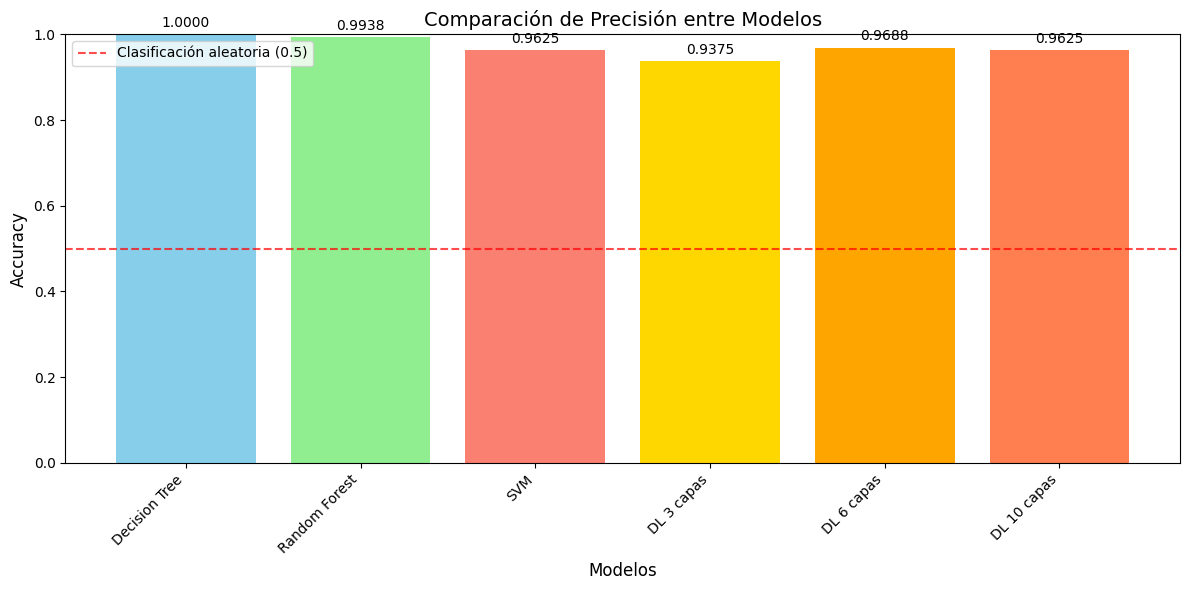

In [ ]:

plt.figure(figsize=(12, 6))

modelos = list(results.keys())
accuracies = list(results.values())

colores = ['skyblue', 'lightgreen', 'salmon', 'gold', 'orange', 'coral']

bars = plt.bar(modelos, accuracies, color=colores[:len(modelos)])

plt.xlabel('Modelos', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparación de Precisión entre Modelos', fontsize=14)
plt.ylim(0, 1)  # accuracy va de 0 a 1
plt.xticks(rotation=45, ha='right')

# Añadir los valores encima de las barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

# Añadir línea de referencia en 0.5
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Clasificación aleatoria (0.5)')

plt.legend()
plt.tight_layout()
plt.show()


#**Modelos no supervisados**

In [ ]:
# REDUCCIÓN DE DIMENSIONALIDAD CON PCA
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import matplotlib.patches as mpatches

# datos escalados(X_scaled)
# X_scaled ya está normalizado con StandardScaler

# Aplicar PCA para reducir a 2 componentes principales
pca = PCA(n_components=2, random_state=21)
X_pca = pca.fit_transform(X_scaled)

print("Análisis de componentes principales (PCA)")

print(f"Varianza explicada por Componente 1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Varianza explicada por Componente 2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Varianza explicada acumulada: {sum(pca.explained_variance_ratio_):.4f}")

# cuánto aporta cada variable original a las componentes
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
print("\nContribución de variables a las componentes principales ")
print(loadings.head(10))


Análisis de componentes principales (PCA)
Varianza explicada por Componente 1: 0.2053
Varianza explicada por Componente 2: 0.1245
Varianza explicada acumulada: 0.3298

Contribución de variables a las componentes principales 
                                  PC1       PC2
Age                         -0.020118  0.047974
Gender                      -0.038798 -0.024120
Country                     -0.009332  0.049585
Student_Working_Status       0.027920 -0.038718
Daily_Social_Media_Hours    -0.167442  0.512059
Screen_Time_Hours           -0.180902  0.478936
Night_Scrolling_Frequency   -0.101340  0.078588
Online_Gaming_Hours         -0.000902 -0.022281
Content_Type_Preference     -0.036141  0.018329
Exercise_Frequency_per_Week  0.061507  0.062996


In [ ]:
# 2a: K-MEANS CLUSTERING

print("K-MEANS CLUSTERING (n_clusters = 3)")

# KMeans
kmeans = KMeans(n_clusters=3, random_state=21, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)  #  datos originales escalados

# Evaluación
silhouette_kmeans = silhouette_score(X_scaled, y_kmeans)
print(f"Silhouette Score (KMeans): {silhouette_kmeans:.4f}")

# Comparar con las etiquetas reales (Burnout_Risk)
# Primero codificamos Burnout_Risk que ya debe estar en y (original)
# y tiene valores ['High', 'Medium', 'Low'] que ya usaste en LabelEncoder
ari_kmeans = adjusted_rand_score(y_encoded, y_kmeans) if 'y_encoded' in dir() else "N/A"
nmi_kmeans = normalized_mutual_info_score(y_encoded, y_kmeans) if 'y_encoded' in dir() else "N/A"

if 'y_encoded' in dir():
    print(f"Adjusted Rand Index vs Burnout_Risk: {ari_kmeans:.4f}")
    print(f"Normalized Mutual Info vs Burnout_Risk: {nmi_kmeans:.4f}")

# Ver distribución de clusters vs clases reales
cross_tab_kmeans = pd.crosstab(y_kmeans, y)
print("\n    Tabla de contingencia KMeans vs Burnout_Risk real   ")
print(cross_tab_kmeans)

# PASO 2b: DBSCAN CLUSTERING

print("DBSCAN CLUSTERING")

# Búsqueda de mejores parámetros para DBSCAN (opcional)
# Usamos valores típicos: eps entre 0.5 y 2, min_samples entre 3 y 10
best_eps = None
best_min_samples = None
best_score = -1
best_n_clusters = 0

print("Buscando mejores parámetros para DBSCAN...")
for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0]:
    for min_samples in [3, 5, 7, 10]:
        dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples)
        labels_temp = dbscan_temp.fit_predict(X_scaled)
        n_clusters_temp = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise = sum(labels_temp == -1)

        # Solo evaluamos si hay más de 1 cluster y menos de 10
        if 1 < n_clusters_temp < 10:
            # Silhouette score solo con puntos no ruido
            mask = labels_temp != -1
            if sum(mask) > 1 and len(set(labels_temp[mask])) > 1:
                score_temp = silhouette_score(X_scaled[mask], labels_temp[mask])
                if score_temp > best_score:
                    best_score = score_temp
                    best_eps = eps
                    best_min_samples = min_samples
                    best_n_clusters = n_clusters_temp

if best_eps is not None:
    print(f"Mejores parámetros encontrados: eps={best_eps}, min_samples={best_min_samples}")
    print(f"Silhouette Score: {best_score:.4f}")
    print(f"Número de clusters encontrados (excluyendo ruido): {best_n_clusters}")
else:
    # Usar valores por defecto si no se encontraron buenos
    best_eps, best_min_samples = 1.2, 5
    print(f"Usando parámetros por defecto: eps={best_eps}, min_samples={best_min_samples}")

# Aplicar DBSCAN con los mejores parámetros
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
y_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise_db = sum(y_dbscan == -1)

print(f"\n    Resultados DBSCAN ")
print(f"Número de clusters encontrados: {n_clusters_db}")
print(f"Número de puntos considerados ruido: {n_noise_db} ({n_noise_db/len(y_dbscan)*100:.1f}%)")

if n_clusters_db > 1:
    mask_db = y_dbscan != -1
    if sum(mask_db) > 1 and len(set(y_dbscan[mask_db])) > 1:
        silhouette_db = silhouette_score(X_scaled[mask_db], y_dbscan[mask_db])
        print(f"Silhouette Score (DBSCAN, excluyendo ruido): {silhouette_db:.4f}")

# Comparación con etiquetas reales (solo puntos no ruido)
if 'y_encoded' in dir() and n_clusters_db > 0:
    mask_no_noise = y_dbscan != -1
    if sum(mask_no_noise) > 0:
        ari_db = adjusted_rand_score(y_encoded[mask_no_noise], y_dbscan[mask_no_noise])
        print(f"Adjusted Rand Index vs Burnout_Risk (sin ruido): {ari_db:.4f}")


K-MEANS CLUSTERING (n_clusters = 3)
Silhouette Score (KMeans): 0.0888

    Tabla de contingencia KMeans vs Burnout_Risk real   
Burnout_Risk  High  Low  Medium
row_0                          
0               38    4     228
1              278    0       0
2              108    0     142
DBSCAN CLUSTERING
Buscando mejores parámetros para DBSCAN...
Usando parámetros por defecto: eps=1.2, min_samples=5

    Resultados DBSCAN 
Número de clusters encontrados: 0
Número de puntos considerados ruido: 798 (100.0%)


VISUALIZACIÓN: Componente 2 vs Componente 1


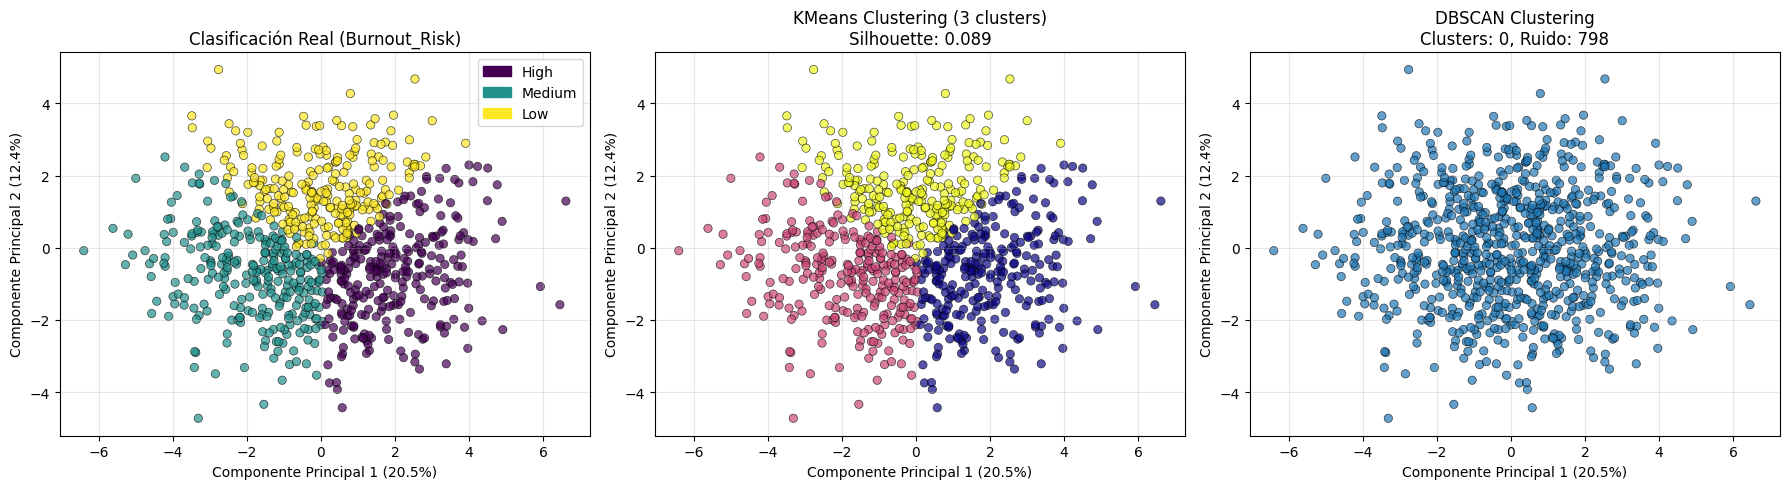

In [ ]:
# PASO 3: VISUALIZACIÓN PC2 vs PC1

print("VISUALIZACIÓN: Componente 2 vs Componente 1")

# Crear figura con subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Ground Truth (Burnout_Risk real)
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded if 'y_encoded' in dir() else y_kmeans,
                           cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
axes[0].set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Clasificación Real (Burnout_Risk)')
axes[0].grid(True, alpha=0.3)

# Crear leyenda para ground truth
legend_elements = []
for i, label in enumerate(['High', 'Medium', 'Low']):
    legend_elements.append(mpatches.Patch(color=scatter1.cmap(scatter1.norm(i)), label=label))
axes[0].legend(handles=legend_elements)

# 2. KMeans Clustering
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans,
                           cmap='plasma', alpha=0.7, edgecolors='k', linewidth=0.5)
axes[1].set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title(f'KMeans Clustering (3 clusters)\nSilhouette: {silhouette_kmeans:.3f}')
axes[1].grid(True, alpha=0.3)

# 3. DBSCAN Clustering
# Asignar colores: -1 (ruido) será gris
cmap_db = plt.cm.tab10
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=y_dbscan,
                           cmap='tab10', alpha=0.7, edgecolors='k', linewidth=0.5,
                           vmin=-1, vmax=n_clusters_db)
axes[2].set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[2].set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[2].set_title(f'DBSCAN Clustering\nClusters: {n_clusters_db}, Ruido: {n_noise_db}')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# **REFERENCIAS BIBLIOGRÁFICAS**

*Dataset.* [Kaggle](https://www.kaggle.com/datasets/hammadansari7/gen-z-mental-wellness-and-digital-lifestyle-patterns)